# Holt-Winters Methods

In [1]:
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('airline-passengers.csv',index_col='Month',parse_dates=True)
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [10]:
df.fillna(method='ffill')

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [12]:
#df.dropna(inplace=True)

In [14]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [20]:
print(df.index.freq)

None


### Setting a DatetimeIndex Frequency

In [23]:
df.index.freq = 'MS'
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

In [25]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


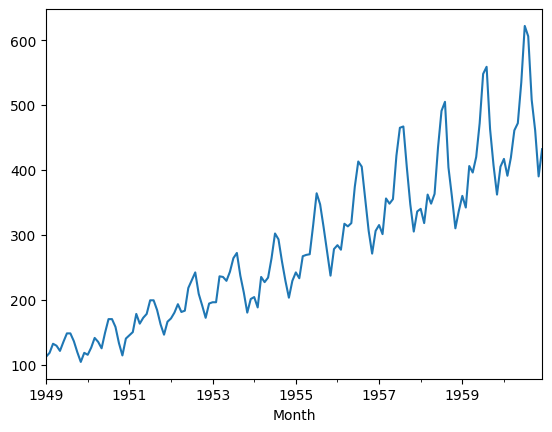

In [29]:
df['Passengers'].plot()
plt.show()

___
## Simple Exponential Smoothing

In [32]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
alpha = 0.15

In [35]:
model_ses12=SimpleExpSmoothing(df['Passengers'])
fitted_model= model_ses12.fit(smoothing_level=alpha,optimized=False)
fitted_model.fittedvalues

Month
1949-01-01    112.000000
1949-02-01    112.000000
1949-03-01    112.900000
1949-04-01    115.765000
1949-05-01    117.750250
                 ...    
1960-08-01    473.417458
1960-09-01    493.304839
1960-10-01    495.509113
1960-11-01    490.332746
1960-12-01    475.282834
Freq: MS, Length: 144, dtype: float64

In [37]:
df['SES12'] = fitted_model.fittedvalues.shift(-1)
df.head()

,Passengers,SES12
Month,,
1949-01-01,112,112.000000
1949-02-01,118,112.900000
1949-03-01,132,115.765000
1949-04-01,129,117.750250
1949-05-01,121,118.237712


___
## Double Exponential Smoothing

In [59]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

mod_add12 = ExponentialSmoothing(df['Passengers'], trend='add')
fitted_model= mod_add12.fit(optimized=True, use_brute=True)
df['DESadd12'] = fitted_model.fittedvalues.shift(-1)
df.head()

,Passengers,SES12,DESadd12,DESmul12,TESadd12,TESmul12
Month,,,,,,
1949-01-01,112,112.000000,114.102394,113.990701,111.979058,1.033698e+10
1949-02-01,118,112.900000,120.040657,120.031669,120.187327,2.667772e+15
1949-03-01,132,115.765000,134.001539,134.235979,134.692544,1.633713e+20
1949-04-01,129,117.750250,131.085845,131.270786,131.391677,3.267158e+25
1949-05-01,121,118.237712,123.110263,123.156267,124.634371,5.581296e+21


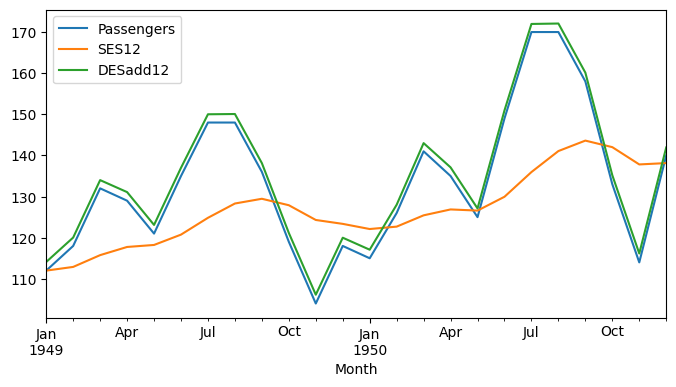

In [61]:
df[['Passengers','SES12','DESadd12']].iloc[:24].plot(figsize=(8,4));

In [63]:
df['DESmul12'] = ExponentialSmoothing(df['Passengers'], trend='mul').fit().fittedvalues.shift(-1)
df.head()

,Passengers,SES12,DESadd12,DESmul12,TESadd12,TESmul12
Month,,,,,,
1949-01-01,112,112.000000,114.102394,113.990701,111.979058,1.033698e+10
1949-02-01,118,112.900000,120.040657,120.031669,120.187327,2.667772e+15
1949-03-01,132,115.765000,134.001539,134.235979,134.692544,1.633713e+20
1949-04-01,129,117.750250,131.085845,131.270786,131.391677,3.267158e+25
1949-05-01,121,118.237712,123.110263,123.156267,124.634371,5.581296e+21


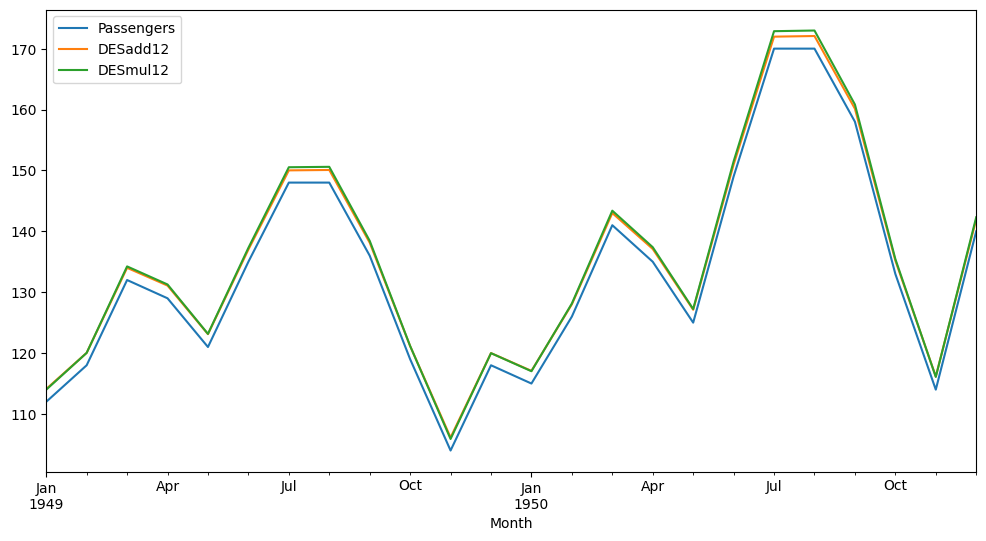

In [65]:
df[['Passengers','DESadd12','DESmul12']].iloc[:24].plot(figsize=(12,6));

___
## Triple Exponential Smoothing

In [68]:
df['TESadd12'] = ExponentialSmoothing(df['Passengers'],trend='add',seasonal='add',seasonal_periods=12).fit().fittedvalues
df.head()

,Passengers,SES12,DESadd12,DESmul12,TESadd12,TESmul12
Month,,,,,,
1949-01-01,112,112.000000,114.102394,113.990701,111.979058,1.033698e+10
1949-02-01,118,112.900000,120.040657,120.031669,120.187327,2.667772e+15
1949-03-01,132,115.765000,134.001539,134.235979,134.692544,1.633713e+20
1949-04-01,129,117.750250,131.085845,131.270786,131.391677,3.267158e+25
1949-05-01,121,118.237712,123.110263,123.156267,124.634371,5.581296e+21


In [70]:
df['TESmul12'] = ExponentialSmoothing(df['Passengers'],trend='mul',seasonal='mul',seasonal_periods=12).fit().fittedvalues
df.head()

C:\Users\Pandhari\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


,Passengers,SES12,DESadd12,DESmul12,TESadd12,TESmul12
Month,,,,,,
1949-01-01,112,112.000000,114.102394,113.990701,111.979058,1.033698e+10
1949-02-01,118,112.900000,120.040657,120.031669,120.187327,2.667772e+15
1949-03-01,132,115.765000,134.001539,134.235979,134.692544,1.633713e+20
1949-04-01,129,117.750250,131.085845,131.270786,131.391677,3.267158e+25
1949-05-01,121,118.237712,123.110263,123.156267,124.634371,5.581296e+21


<Axes: xlabel='Month'>

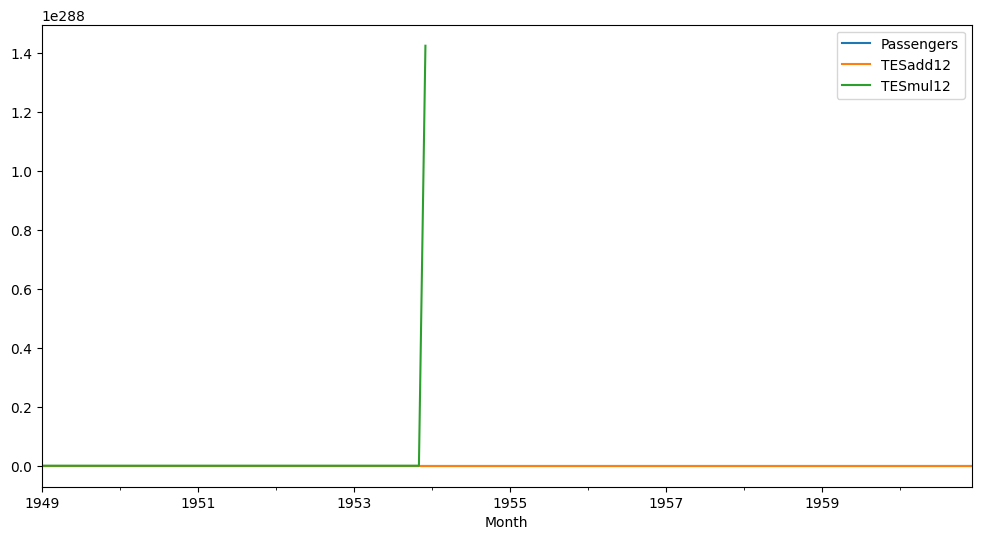

In [72]:
df[['Passengers','TESadd12','TESmul12']].plot(figsize=(12,6))

<Axes: xlabel='Month'>

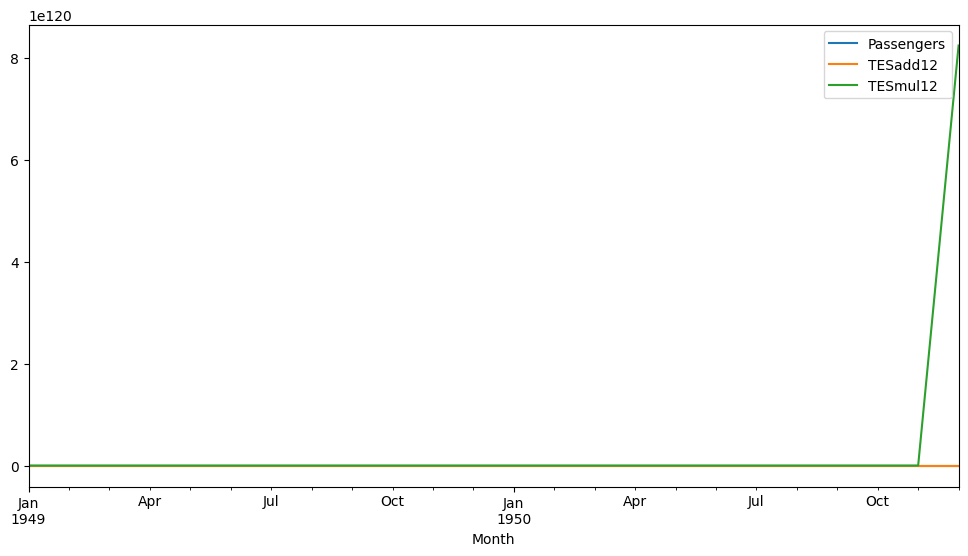

In [75]:
df[['Passengers','TESadd12','TESmul12']].iloc[:24].plot(figsize=(12,6))